# Two-Track CCRG Toxicity Dataset Family — Demo

This notebook is a **runnable, annotated walk-through of `data.py`**, the
stdlib-only assembler for the *Two-Track CCRG Toxicity* dataset family.

The full corpus is **37,707 examples** in the `exp_sel_data_out` schema,
organised into the two real source corpora and three role-distinct components:

| Component (`metadata_record_type`) | Rows | Role |
|---|---|---|
| `content_pair`  | 18,853 | ParaDetox human **toxic ↔ neutral** flips — the non-circular *content* perturbation P (`text_on`/`text_off`) |
| `surface_pair`  |    546 | gpt-4o-mini **toxic → toxic** paraphrases — the *surface-invariance* control (`input`/`text_paired`) |
| `classification`| 18,308 | civil_comments rows + binary toxicity label + **frozen multi-label sub-context labels** (severe_toxicity / obscene / threat / insult / identity_attack / sexual_explicit) |

These cluster-/group-level units (pairs, sub-contexts, co-activation overlap)
are what the downstream experiments use to organise SAE latents into more
reliable units of analysis than single latents.

**What this demo does.** Instead of re-downloading the three raw sources, it
loads a small curated slice of the *assembled* output from GitHub, then runs the
actual `data.py` analysis code on it — the text/key helpers, the leakage-safe
fold **invariant checker** (`verify`), and the **manifest builder**
(`build_summary`: per-sub-context power, co-occurrence counts, and the
**Jaccard overlap matrix** that separates the C-track `insult↔obscene` shared
support from the K-track disjoint attributes). The final cell visualises the
real full-corpus statistics carried in the data's `metadata`.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# data.py is STDLIB-ONLY. The demo only adds matplotlib + numpy for the summary
# plots. Both are pre-installed on Colab, so install them locally only (behind
# the google.colab guard) to match Colab's environment without corrupting it.
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


### Imports
The original `data.py` import block (stdlib only), plus `numpy`/`matplotlib` for the demo's plots.

In [2]:
from __future__ import annotations
import collections
import hashlib
import json
import os
import re

# additional imports for the demo visualization (not in the original data.py)
import numpy as np
import matplotlib.pyplot as plt

### Load the data (GitHub URL with local fallback)

`mini_demo_data.json` is a curated subset of the assembled corpus: 90 diverse
examples across both dataset groups (all three record types, both toxicity
labels, every fold, and a spread of sub-context labels) **plus** the full
precomputed `metadata` manifest for the real 37,707-row statistics.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-7ee30c-catching-silent-feature-absorption-in-fr/main/round-1/dataset-3/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print("Top-level keys:", list(data.keys()))
print("Full-corpus title:", data["metadata"]["title"])
print("Best 2 datasets :", data["metadata"]["best_2_datasets"])
for d in data["datasets"]:
    rt = collections.Counter(r["metadata_record_type"] for r in d["examples"])
    print(f"  group {d['dataset']:<14} {len(d['examples'])} examples  {dict(rt)}")

Top-level keys: ['metadata', 'datasets']
Full-corpus title: Two-Track CCRG Toxicity Dataset Family
Best 2 datasets : ['paradetox', 'civil_comments']
  group paradetox      34 examples  {'surface_pair': 4, 'content_pair': 30}
  group civil_comments 56 examples  {'classification': 50, 'surface_pair': 6}


## Config

The constants that govern the schema and the summary, copied verbatim from
`data.py`, plus one demo-only knob (`MAX_EXAMPLES_PER_GROUP`) controlling how
many of the loaded examples to process. Start at the minimum and scale up.

> Note: the curated slice is far below `N_MIN = 150`, so every sub-context will
> read `descriptive_only` *on the slice*. The real `inferential@0.5` power
> verdicts come from the full-corpus `metadata` (shown in the final plot).

In [5]:
# --- constants copied verbatim from data.py ---
SUB_ATTRS = ["severe_toxicity", "obscene", "threat", "insult",
             "identity_attack", "sexual_explicit"]
FLOAT_AXES = ["toxicity"] + SUB_ATTRS
PRIMARY_THRESHOLD, FALLBACK_THRESHOLD, N_MIN = 0.5, 0.3, 150
FOLDS = ("train", "val", "test")

# --- demo-only tunable: how many loaded examples per dataset group to process ---
# The mini slice holds up to ~56 examples/group; the full corpus is 37,707 rows.
# This demo is near-instant, so we process the entire loaded slice.
# MAX_EXAMPLES_PER_GROUP = 8     # absolute-minimum first pass (a few rows/group)
MAX_EXAMPLES_PER_GROUP = 1000    # <-- process every loaded example (full slice)

## 1. Text / key helpers

Verbatim from `data.py`. `clean_text` normalises HTML entities and whitespace;
`norm_key` lowercases and strips punctuation to a canonical key (the basis for
leakage-safe grouping); `sha16`/`ssid_of` give stable content ids; and
`fold_from_key` deterministically hashes a key into a train/val/test fold.

In [6]:
_WS = re.compile(r"\s+")
_PUNCT = re.compile(r"[^\w\s]", flags=re.UNICODE)
_HTML_ENT = re.compile(r"&(amp|lt|gt|quot|#39|nbsp|apos);")
_HTML_ENT_MAP = {"&amp;": "&", "&lt;": "<", "&gt;": ">", "&quot;": '"',
                 "&#39;": "'", "&nbsp;": " ", "&apos;": "'"}


def log(msg):
    print("[data.py] " + msg, flush=True)


def clean_text(text):
    if text is None:
        return ""
    t = _HTML_ENT.sub(lambda m: _HTML_ENT_MAP.get(m.group(0), m.group(0)), str(text))
    t = t.replace(" ", " ").replace("\r", " ").replace("\n", " ")
    return _WS.sub(" ", t).strip()


def norm_key(text):
    t = _PUNCT.sub(" ", clean_text(text).lower())
    return _WS.sub(" ", t).strip()


def sha16(text):
    return hashlib.sha1(text.encode("utf-8")).hexdigest()[:16]


def ssid_of(toxic_text):
    return "ssid_" + sha16(norm_key(toxic_text))


def fold_from_key(key, ratios=(0.8, 0.1, 0.1)):
    bucket = int(hashlib.sha1(key.encode("utf-8")).hexdigest(), 16) % 1000
    tcut = int(ratios[0] * 1000)
    vcut = tcut + int(ratios[1] * 1000)
    return "train" if bucket < tcut else ("val" if bucket < vcut else "test")


# --- demo: the helpers in action ---
sample = "  He had STEEL balls &amp; nerve!! "
print("clean_text :", repr(clean_text(sample)))
print("norm_key   :", repr(norm_key(sample)))
print("ssid_of    :", ssid_of(sample))
print("fold_from_key:", fold_from_key(norm_key(sample)))

clean_text : 'He had STEEL balls & nerve!!'
norm_key   : 'he had steel balls nerve'
ssid_of    : ssid_3e3cda85053a4523
fold_from_key: train


## 2. Grouping primitives: Union-Find + the row schema

`UF` is the union-find used to merge texts that refer to the same content
(toxic/neutral pairs, paraphrases) into one leakage-safe component so a content
key never lands in two folds. `make_row` defines the **exact `exp_sel_data_out`
row schema** every example follows. Both are copied verbatim from `data.py`.

In [7]:
class UF:
    def __init__(self):
        self.p = {}

    def find(self, x):
        self.p.setdefault(x, x)
        root = x
        while self.p[root] != root:
            root = self.p[root]
        while self.p[x] != root:
            self.p[x], x = root, self.p[x]
        return root

    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra != rb:
            self.p[ra] = rb


def make_row(rid, input_text, output_label, fold, record_type, source,
             origin_source, toxicity_label, *, text_on=None, text_off=None,
             text_paired=None, pair_id=None, ssid=None, is_content_pair=False,
             is_surface_pair=False, subcontext_labels=None, subcontext_floats=None,
             subcontext_threshold=None, judge_pass=None, gen_model=None,
             surface_metrics=None):
    if subcontext_labels is None:
        subcontext_labels = {a: None for a in SUB_ATTRS}
    if subcontext_floats is None:
        subcontext_floats = {a: None for a in FLOAT_AXES}
    return {
        "input": input_text,
        "output": output_label,
        "metadata_id": rid,
        "metadata_fold": fold,
        "metadata_record_type": record_type,
        "metadata_source": source,
        "metadata_origin_source": origin_source,
        "metadata_toxicity_label": int(toxicity_label),
        "metadata_text_on": text_on,
        "metadata_text_off": text_off,
        "metadata_text_paired": text_paired,
        "metadata_pair_id": pair_id,
        "metadata_source_sentence_id": ssid,
        "metadata_is_content_pair": bool(is_content_pair),
        "metadata_is_surface_pair": bool(is_surface_pair),
        "metadata_subcontext_labels": subcontext_labels,
        "metadata_subcontext_floats": subcontext_floats,
        "metadata_subcontext_threshold": subcontext_threshold,
        "metadata_judge_pass": judge_pass,
        "metadata_gen_model": gen_model,
        "metadata_surface_metrics": surface_metrics,
    }


# --- demo: UF merges two related keys into one component ---
uf = UF()
uf.union("k:" + norm_key("he is a fool"), "k:" + norm_key("he is unwise"))
print("same component:",
      uf.find("k:" + norm_key("he is a fool")) == uf.find("k:" + norm_key("he is unwise")))

# --- demo: make_row reproduces the loaded row schema exactly ---
demo_row = make_row("tox_demo_000000", "you are a fool", "toxic", "train",
                    "classification", "civil_comments", "civil_comments", 1,
                    ssid=ssid_of("you are a fool"),
                    subcontext_labels={a: 0 for a in SUB_ATTRS},
                    subcontext_floats={a: 0.0 for a in FLOAT_AXES},
                    subcontext_threshold=PRIMARY_THRESHOLD)
loaded_keys = set(data["datasets"][0]["examples"][0].keys())
print("make_row keys match loaded schema:", set(demo_row.keys()) == loaded_keys)

same component: True
make_row keys match loaded schema: True


## 3. Flatten the dataset family into rows

Downstream consumers flatten `datasets[*].examples` and filter on
`metadata_record_type`. We do exactly that, capping each group at
`MAX_EXAMPLES_PER_GROUP` from the config cell.

In [8]:
rows = []
for d in data["datasets"]:
    rows.extend(d["examples"][:MAX_EXAMPLES_PER_GROUP])

print(f"Flattened {len(rows)} rows from {len(data['datasets'])} groups "
      f"(<= {MAX_EXAMPLES_PER_GROUP} per group)")
print("by record_type:", dict(collections.Counter(r["metadata_record_type"] for r in rows)))
print("by fold       :", dict(collections.Counter(r["metadata_fold"] for r in rows)))
print("by toxicity   :", dict(collections.Counter(r["metadata_toxicity_label"] for r in rows)))

Flattened 90 rows from 2 groups (<= 1000 per group)
by record_type: {'surface_pair': 10, 'content_pair': 30, 'classification': 50}
by fold       : {'train': 78, 'val': 8, 'test': 4}
by toxicity   : {1: 82, 0: 8}


## 4. Verify the leakage-safe invariants

`verify` (verbatim) asserts the structural guarantees the family relies on:
every row has a valid fold; no `pair_id` or `source_sentence_id` spans folds;
**no normalized text appears in more than one fold** (doc-level leakage
safety); and all labels/floats are in range. Because the slice is a subset of
the leakage-safe full corpus, these invariants still hold.

In [9]:
def verify(rows):
    assert all(r["metadata_fold"] in FOLDS for r in rows), "bad fold"
    pf, sf, kf = collections.defaultdict(set), collections.defaultdict(set), collections.defaultdict(set)
    for r in rows:
        if r["metadata_pair_id"]:
            pf[r["metadata_pair_id"]].add(r["metadata_fold"])
        if r["metadata_source_sentence_id"]:
            sf[r["metadata_source_sentence_id"]].add(r["metadata_fold"])
        for m in (r["input"], r["metadata_text_off"], r["metadata_text_paired"]):
            if m:
                kf[norm_key(m)].add(r["metadata_fold"])
    assert not [p for p, s in pf.items() if len(s) > 1], "pair_id spans folds"
    assert not [s for s, v in sf.items() if len(v) > 1], "ssid spans folds"
    leaks = [k for k, v in kf.items() if len(v) > 1]
    assert not leaks, f"{len(leaks)} texts span folds (leakage)"
    for r in rows:
        assert r["metadata_toxicity_label"] in (0, 1)
        for v in r["metadata_subcontext_labels"].values():
            assert v in (0, 1, None)
        if r["metadata_subcontext_floats"]:
            for v in r["metadata_subcontext_floats"].values():
                assert v is None or 0.0 <= v <= 1.0
    log("Invariants PASSED (folds, pair_id, ssid, no text in >1 fold, binary labels, floats in [0,1])")


verify(rows)

[data.py] Invariants PASSED (folds, pair_id, ssid, no text in >1 fold, binary labels, floats in [0,1])


## 5. Build the manifest summary

`build_summary` (verbatim, with its helper `group_of`) recomputes the manifest:
totals by record_type / group / fold, the per-sub-context **power report**
(threshold 0.5 and 0.3 vs `N_MIN`), the sub-context **co-occurrence counts**,
and the **Jaccard overlap matrix**. We run it on the flattened slice — the same
code that produced `data_summary.json` for the full corpus.

In [10]:
def group_of(r):
    return "paradetox" if r["metadata_origin_source"] == "paradetox" else "civil_comments"


def build_summary(rows, s3_stats, cross_collisions, dropped):
    cls = [r for r in rows if r["metadata_record_type"] == "classification"]
    counts = {thr: {a: {f: 0 for f in FOLDS} for a in SUB_ATTRS}
              for thr in (PRIMARY_THRESHOLD, FALLBACK_THRESHOLD)}
    for r in cls:
        fl, fold = r["metadata_subcontext_floats"], r["metadata_fold"]
        for a in SUB_ATTRS:
            for thr in (PRIMARY_THRESHOLD, FALLBACK_THRESHOLD):
                if (fl.get(a) or 0.0) >= thr:
                    counts[thr][a][fold] += 1
    sub_report = {}
    for a in SUB_ATTRS:
        rep = {}
        for thr in (PRIMARY_THRESHOLD, FALLBACK_THRESHOLD):
            pf = counts[thr][a]
            tot = sum(pf.values())
            rep[f"threshold_{thr}"] = {"per_fold": pf, "total": tot,
                                       "meets_n_min_overall": tot >= N_MIN,
                                       "meets_n_min_each_eval_fold": all(pf[f] >= N_MIN for f in ("val", "test"))}
        if rep[f"threshold_{PRIMARY_THRESHOLD}"]["total"] >= N_MIN:
            rep["status"] = "inferential@0.5"
        elif rep[f"threshold_{FALLBACK_THRESHOLD}"]["total"] >= N_MIN:
            rep["status"] = "inferential@0.3_fallback"
        else:
            rep["status"] = "descriptive_only"
        sub_report[a] = rep

    toxic_cls = [r for r in cls if r["metadata_toxicity_label"] == 1]
    cooc = {a: {b: 0 for b in SUB_ATTRS} for a in SUB_ATTRS}
    marg = {a: 0 for a in SUB_ATTRS}
    for r in toxic_cls:
        present = [a for a in SUB_ATTRS if r["metadata_subcontext_labels"].get(a) == 1]
        for a in present:
            marg[a] += 1
            for b in present:
                cooc[a][b] += 1
    overlap = {a: {b: (round(cooc[a][b] / (marg[a] + marg[b] - cooc[a][b]), 3)
                        if (marg[a] + marg[b] - cooc[a][b]) else 0.0) for b in SUB_ATTRS}
               for a in SUB_ATTRS}

    grp = collections.Counter(group_of(r) for r in rows)
    return {
        "title": "Two-Track CCRG Toxicity Dataset Family",
        "best_2_datasets": ["paradetox", "civil_comments"],
        "components": {
            "content_pair": "ParaDetox human toxic<->neutral CONTENT-FLIP pairs (non-circular perturbation P)",
            "surface_pair": "OpenRouter-generated toxic->toxic SURFACE-FLIP pairs (surface-invariance control)",
            "classification": "civil_comments rows + binary toxicity label + FROZEN multi-label sub-context labels",
        },
        "dataset_groups": {
            "paradetox": "ParaDetox content_pair rows + paradetox-origin surface_pair rows (Logacheva et al. ACL 2022; openrail++)",
            "civil_comments": "civil_comments classification rows + civil-origin surface_pair rows (Borkan et al. 2019; CC0 1.0)",
        },
        "canonical_representation": "ONE row per pair (content_pair: text_on/text_off; surface_pair: input/text_paired); classification: one row per comment. Surface pairs grouped by metadata_origin_source.",
        "totals": {
            "rows": len(rows),
            "by_record_type": dict(collections.Counter(r["metadata_record_type"] for r in rows)),
            "by_dataset_group": dict(grp),
            "by_fold": dict(collections.Counter(r["metadata_fold"] for r in rows)),
            "by_toxicity_label": {str(k): v for k, v in collections.Counter(r["metadata_toxicity_label"] for r in rows).items()},
        },
        "subcontext_report": sub_report,
        "subcontext_marginal_toxic_cls@0.5": marg,
        "subcontext_cooccurrence_counts@0.5": cooc,
        "subcontext_jaccard_overlap@0.5": overlap,
        "surface_generation": s3_stats,
        "cross_source_collisions_reconciled": cross_collisions,
        "grouping_rows_dropped_fold_conflict": dropped,
        "thresholds": {"primary": PRIMARY_THRESHOLD, "fallback": FALLBACK_THRESHOLD,
                       "clean_negative_ceiling": 0.2, "n_min": N_MIN},
    }


# s3_stats = the real surface-generation audit carried in the loaded metadata
summary = build_summary(rows, data["metadata"].get("surface_generation", {}),
                        cross_collisions=0, dropped=0)

print("TOTALS (on the processed slice):")
print("  rows            :", summary["totals"]["rows"])
print("  by_record_type  :", summary["totals"]["by_record_type"])
print("  by_dataset_group:", summary["totals"]["by_dataset_group"])
print("  by_fold         :", summary["totals"]["by_fold"])
print("\nSub-context status on the slice (expected: descriptive_only — slice << N_MIN):")
for a in SUB_ATTRS:
    print(f"  {a:<16} {summary['subcontext_report'][a]['status']}")
print("\nSlice Jaccard overlap insult<->obscene:",
      summary["subcontext_jaccard_overlap@0.5"]["insult"]["obscene"])

TOTALS (on the processed slice):
  rows            : 90
  by_record_type  : {'surface_pair': 10, 'content_pair': 30, 'classification': 50}
  by_dataset_group: {'paradetox': 34, 'civil_comments': 56}
  by_fold         : {'train': 78, 'val': 8, 'test': 4}

Sub-context status on the slice (expected: descriptive_only — slice << N_MIN):
  severe_toxicity  descriptive_only
  obscene          descriptive_only
  threat           descriptive_only
  insult           descriptive_only
  identity_attack  descriptive_only
  sexual_explicit  descriptive_only

Slice Jaccard overlap insult<->obscene: 0.194


## Results — full-corpus statistics

The slice is intentionally tiny, so for the headline numbers we read the
**precomputed full-corpus manifest** carried in `data["metadata"]` (the output
of running `build_summary` on all 37,707 rows). Three views:

1. **Component sizes** — the two source groups and the three record types.
2. **Sub-context power** — positives at threshold 0.5 per attribute, coloured by
   power status (`inferential@0.5` vs `descriptive_only`).
3. **Jaccard overlap matrix** — the C-track vs K-track separation: `insult↔obscene`
   share ≈0.245 support (C-track / feature-splitting story) while `threat` and
   `identity_attack` are <0.05 disjoint (K-track).

record_type        slice   full corpus
content_pair          30         18853
surface_pair          10           546
classification        50         18308
TOTAL                 90         37707


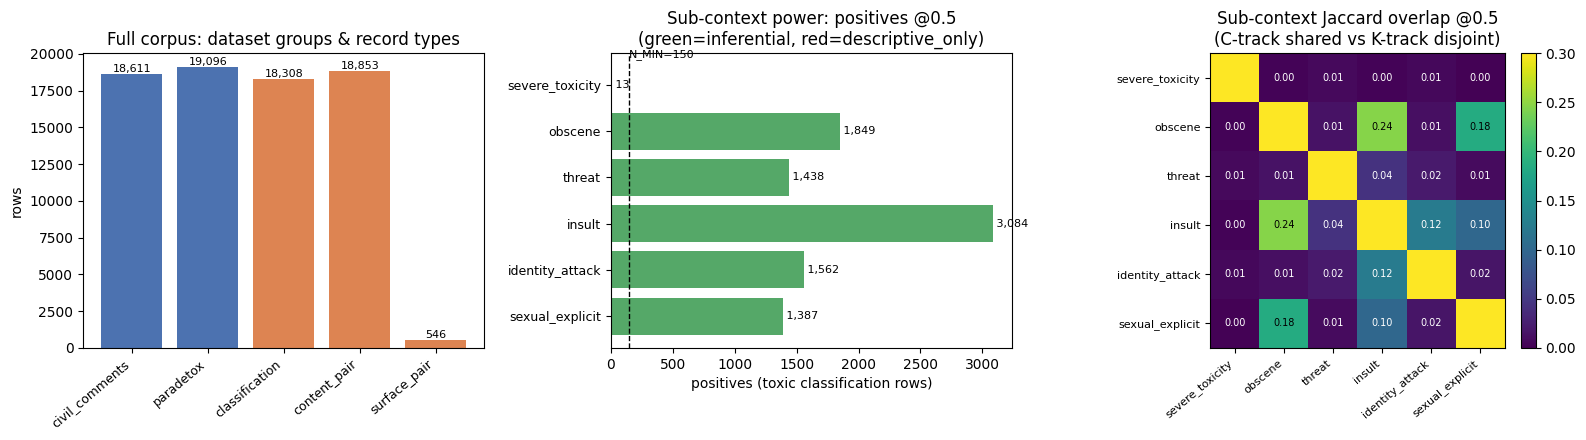


Headline structure (full corpus):
  insult <-> obscene Jaccard : 0.245 (C-track: shared support)
  threat <-> identity_attack : 0.022 (K-track: ~disjoint)
  surface-generation judge pass rate: 0.7063


In [11]:
meta = data["metadata"]

# ---- table: slice-derived vs full-corpus record_type counts ----
full_rt = meta["totals"]["by_record_type"]
slice_rt = summary["totals"]["by_record_type"]
print(f"{'record_type':<16}{'slice':>8}{'full corpus':>14}")
for rt in ("content_pair", "surface_pair", "classification"):
    print(f"{rt:<16}{slice_rt.get(rt, 0):>8}{full_rt.get(rt, 0):>14}")
print(f"{'TOTAL':<16}{summary['totals']['rows']:>8}{meta['totals']['rows']:>14}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (1) component / group sizes
groups = meta["totals"]["by_dataset_group"]
rts = meta["totals"]["by_record_type"]
labels = list(groups.keys()) + list(rts.keys())
vals = list(groups.values()) + list(rts.values())
colors = ["#4C72B0", "#4C72B0", "#DD8452", "#DD8452", "#DD8452"]
axes[0].bar(range(len(labels)), vals, color=colors)
axes[0].set_xticks(range(len(labels)))
axes[0].set_xticklabels(labels, rotation=40, ha="right", fontsize=9)
axes[0].set_title("Full corpus: dataset groups & record types")
axes[0].set_ylabel("rows")
for i, v in enumerate(vals):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8)

# (2) sub-context power at threshold 0.5
rep = meta["subcontext_report"]
totals05 = [rep[a]["threshold_0.5"]["total"] for a in SUB_ATTRS]
status = [rep[a]["status"] for a in SUB_ATTRS]
bar_c = ["#55A868" if s.startswith("inferential") else "#C44E52" for s in status]
axes[1].barh(range(len(SUB_ATTRS)), totals05, color=bar_c)
axes[1].set_yticks(range(len(SUB_ATTRS)))
axes[1].set_yticklabels(SUB_ATTRS, fontsize=9)
axes[1].invert_yaxis()
axes[1].axvline(N_MIN, color="black", ls="--", lw=1)
axes[1].text(N_MIN, -0.6, f"N_MIN={N_MIN}", fontsize=8)
axes[1].set_title("Sub-context power: positives @0.5\n(green=inferential, red=descriptive_only)")
axes[1].set_xlabel("positives (toxic classification rows)")
for i, v in enumerate(totals05):
    axes[1].text(v, i, f" {v:,}", va="center", fontsize=8)

# (3) Jaccard overlap heatmap
jac = meta["subcontext_jaccard_overlap@0.5"]
M = np.array([[jac[a][b] for b in SUB_ATTRS] for a in SUB_ATTRS])
im = axes[2].imshow(M, cmap="viridis", vmin=0, vmax=0.3)
axes[2].set_xticks(range(len(SUB_ATTRS)))
axes[2].set_xticklabels(SUB_ATTRS, rotation=40, ha="right", fontsize=8)
axes[2].set_yticks(range(len(SUB_ATTRS)))
axes[2].set_yticklabels(SUB_ATTRS, fontsize=8)
axes[2].set_title("Sub-context Jaccard overlap @0.5\n(C-track shared vs K-track disjoint)")
for i in range(len(SUB_ATTRS)):
    for j in range(len(SUB_ATTRS)):
        if i != j:
            axes[2].text(j, i, f"{M[i, j]:.2f}", ha="center", va="center",
                         color="white" if M[i, j] < 0.18 else "black", fontsize=7)
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print("\nHeadline structure (full corpus):")
print("  insult <-> obscene Jaccard :", jac["insult"]["obscene"], "(C-track: shared support)")
print("  threat <-> identity_attack :", jac["threat"]["identity_attack"], "(K-track: ~disjoint)")
print("  surface-generation judge pass rate:", meta["surface_generation"]["judge_pass_rate"])